Text(0, 0.5, 'Doppler b parameter (km/s)')

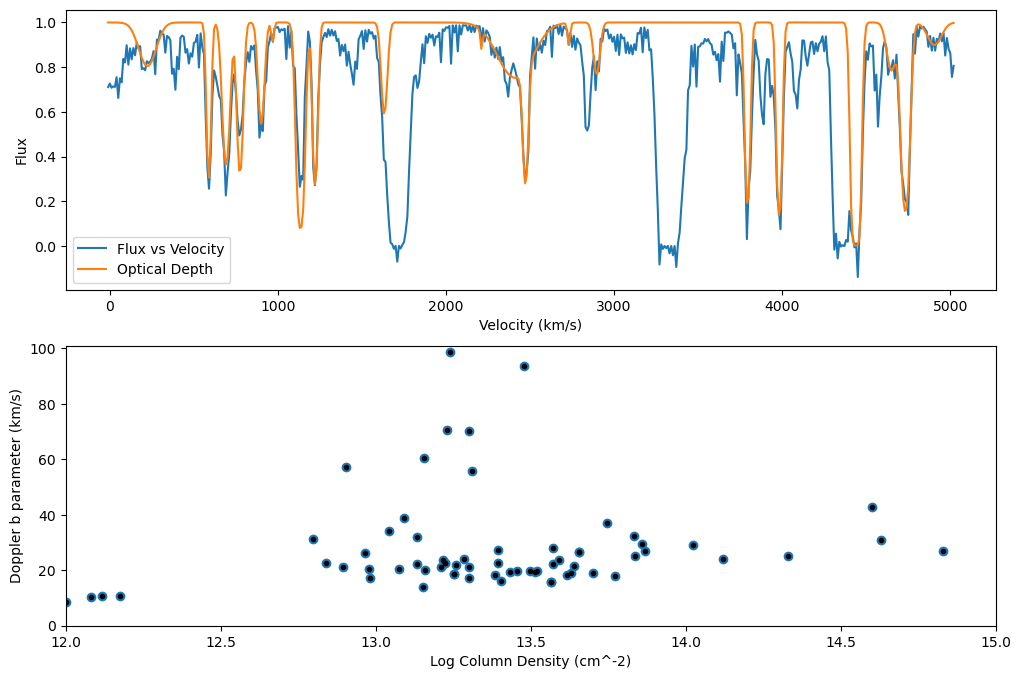

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize
from scipy import stats
import math

filename = "los-Copy1.00000.fHI"
vel1,flux1 = np.loadtxt(filename,delimiter = ',', unpack = True, skiprows = 2)
vel = []
flux = []
for i in range(504):
    vel.append(vel1[i])
    flux.append(flux1[i])
fig, axs = plt.subplots(2,figsize = (12,8))
axs[0].plot(vel, flux, label = 'Flux vs Velocity')
axs[0].set_ylabel('Flux')
axs[0].set_xlabel('Velocity (km/s)')

filename = "los.00000 (1).bN"
WL, ro, b, dWL, dro, db, chisq = np.loadtxt(filename, unpack = True)
filename1 = "los-Copy1.00001.bN"
WL2, ro2, b2, dWL2, dro2, db2, chisq2 = np.loadtxt(filename1, unpack = True)
filename1 = "los-Copy1.00001.bN"
WL3, ro3, b3, dWL3, dro3, db3, chisq3 = np.loadtxt(filename, unpack = True)
filename1 = "los-Copy1.00001.bN"
WL4, ro4, b4, dWL4, dro4, db4, chisq4 = np.loadtxt(filename, unpack = True)

WL1 = []
ro1 = []
dWL1 = []
dro1 = []
db1 = []
b1 = []
chisq1 = []

for i in range(len(chisq)):
    if 0.1 < chisq[i] < 3  and 8 < b[i] < 100 and 12 < ro[i] < 15 and np.isfinite(chisq[i]) and np.isfinite(db[i]) and np.isfinite(dro[i]) and np.isfinite(ro[i]) and np.isfinite(b[i]):
        WL1.append(WL[i])
        ro1.append(ro[i])
        b1.append(b[i])
        dWL1.append(dWL[i])
        dro1.append(dro[i])
        db1.append(db[i])
        chisq1.append(chisq[i])   
for i in range(len(chisq2)):
    if 0.1 < chisq2[i] < 3  and 8 < b2[i] < 100 and 12 < ro2[i] < 15 and np.isfinite(chisq2[i]) and np.isfinite(db2[i]) and np.isfinite(dro2[i]) and np.isfinite(ro2[i]) and np.isfinite(b2[i]):
        WL1.append(WL[i])
        ro1.append(ro[i])
        b1.append(b[i])
        dWL1.append(dWL[i])
        dro1.append(dro[i])
        db1.append(db[i])
        chisq1.append(chisq[i])      
Cm = 4.5e-18
c = 3e5
vi_lst = []
for i in WL1:
    vi = 3e5 * ((i / (4*1216)) - 1)
    vi_lst.append(vi)   
def tfit(num):
    sum1 = 0
    for i in range(len(WL1)):
        A = (10**ro1[i] * c) / (b1[i] * np.sqrt(np.pi))
        B = ((num - vi_lst[i]) ** 2) / (b1[i] ** 2)
        sum1 += A * np.exp(-B)
    val = Cm * sum1
    return val  

axs[0].plot(vel,np.exp(-tfit(vel)), label = 'Optical Depth')
axs[0].legend()

axs[1].errorbar(ro1, b1, dro1, fmt = 'k.', label = 'Errors',capsize = 0)
axs[1].plot(ro1, b1, 'o')
axs[1].set_xlim(12,15)
axs[1].set_ylim(0,101)
axs[1].set_xlabel('Log Column Density (cm^-2)')
axs[1].set_ylabel('Doppler b parameter (km/s)')


In [11]:
# Part B
import scipy
# Conversion of Log10(N) to Ln(N)
x = np.array(ro1) * np.log(10)
dx = np.array(dro1) * np.log(10)
N0 = 3e13
xmax = np.log(1.0e15)
xmin = np.log(1.0e12)

def ifun2(x,b,t,bi,xi,dbi,dxi):
    bt = t[0]* ((np.exp(x)/N0)**t[1])
    bstar = bt* (t[3]/t[4])**(1/t[4])
    p = (t[4] * np.exp(x * t[2]) * ((bstar/b)**t[3]) * np.exp(-(bstar/b)**t[4]) ) / ( bstar * scipy.special.gamma((t[3]-1)/t[4]))
    v = np.exp(- ((b - bi) ** 2) / (2 * (dbi ** 2)) ) 
    v1 = np.exp(- ((x - xi) **2) / (2 * (dxi ** 2)) )
    num = p * v * v1
    return num
             
def llfun2(t):
    ret = 0
    if(t[2] == 0):
        fact0 = 1/(xmax-xmin)
    else:
        fact0 = t[2]/(np.exp(t[2]*xmax)-np.exp(t[2]*xmin))
    for i in range(len(x)):
        C1 = (2 * np.pi * dx[i] * db1[i])
        fact = fact0 / C1
        b_lim = [max(0, b1[i] - 5*db1[i]), b1[i] + 5*db1[i]]
        x_lim = [max(xmin, x[i] - 5*dx[i]), min(xmax, x[i] + 5*dx[i])]
        v = scipy.integrate.dblquad(ifun2,b_lim[0],b_lim[1],x_lim[0],x_lim[1],args=(t,b1[i],x[i],db1[i],dx[i]))
        if(v[0] > 0): 
            ret -= np.log(fact * v[0])
    print(t,ret)
    return ret

't = [b0, β, α, ϕ, Φ]'
t0 = [15, 0.2, 0.2, 3, 3]

print(llfun2(t0))

[15, 0.2, 0.2, 3, 3] 459.82406896330247
459.82406896330247


C:\Users\barre\anaconda3\Lib\site-packages\scipy\integrate\_quadpack_py.py:1225: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  quad_r = quad(f, low, high, args=args, full_output=self.full_output,


In [12]:
# Part C
from timeit import default_timer as timer # time all methods
start_time = timer()
't = [b0, β, α, ϕ, Φ]'
t0 = [23.10359169  0.2222904  -0.05935949  3.82093482  2.68905924]
t0 = np.array(t0)
bounds0 = scipy.optimize.Bounds()
bounds0.lb = np.array([3, -1, -1, 2, 0.5])
bounds0.ub = np.array([50, 2,  1, 8, 6])
res = scipy.optimize.minimize(llfun2, t0, bounds = bounds0)
print("optimization time=%g"%(timer()-start_time))
print(res)
# [19.14870967  0.19073111 -0.02311224  8.          5.27297551] 176.9088095470925

[19.14870967  0.19073111 -0.02311224  8.          5.27297551] 577.721158786018
[19.14870968  0.19073111 -0.02311224  8.          5.27297551] 577.7211587226776
[19.14870967  0.19073112 -0.02311224  8.          5.27297551] 577.7211586553802
[19.14870967  0.19073111 -0.02311223  8.          5.27297551] 577.7211587946875
[19.14870967  0.19073111 -0.02311224  7.99999999  5.27297551] 577.7211585459786
[19.14870967  0.19073111 -0.02311224  8.          5.27297552] 577.7211588256076
[25.48274857  2.         -0.89006533  2.          1.31401326] 1097.748202829124
[25.48274858  2.         -0.89006533  2.          1.31401326] 1097.7482030721462
[25.48274857  1.99999999 -0.89006533  2.          1.31401326] 1097.7481919804861
[25.48274857  2.         -0.89006532  2.          1.31401326] 1097.748201396813
[25.48274857  2.         -0.89006533  2.00000001  1.31401326] 1097.7482049130078
[25.48274857  2.         -0.89006533  2.          1.31401327] 1097.7482141912512
[19.28102046  0.22852466 -0.04122189 

[23.13072078  0.22447717 -0.05839937  3.80065563  2.67478655] 448.86998961824116
[23.13072077  0.22447718 -0.05839937  3.80065563  2.67478655] 448.86998990250106
[23.13072077  0.22447717 -0.05839936  3.80065563  2.67478655] 448.8699895643324
[23.13072077  0.22447717 -0.05839937  3.80065564  2.67478655] 448.86998959528484
[23.13072077  0.22447717 -0.05839937  3.80065563  2.67478656] 448.86998958259534
[22.72609595  0.19194974 -0.07323276  4.10423598  2.88811746] 500.44828241715544
[22.72609596  0.19194974 -0.07323276  4.10423598  2.88811746] 500.44828245551014
[22.72609595  0.19194975 -0.07323276  4.10423598  2.88811746] 500.44828231672165
[22.72609595  0.19194974 -0.07323275  4.10423598  2.88811746] 500.4482823422818
[22.72609595  0.19194974 -0.07323276  4.10423599  2.88811746] 500.4482825239345
[22.72609595  0.19194974 -0.07323276  4.10423598  2.88811747] 500.4482824301274
[23.12805928  0.22426322 -0.05849694  3.80265249  2.67618977] 448.85658085019674
[23.12805929  0.22426322 -0.0584

[23.10720107  0.22258644 -0.05926159  3.81830191  2.68718687] 448.7541858418444
[23.10720106  0.22258645 -0.05926159  3.81830191  2.68718687] 448.7541861088297
[23.10720106  0.22258644 -0.05926158  3.81830191  2.68718687] 448.75418578555633
[23.10720106  0.22258644 -0.05926159  3.81830192  2.68718687] 448.75418582019086
[23.10720106  0.22258644 -0.05926159  3.81830191  2.68718688] 448.7541858064489
[23.10712026  0.22257995 -0.05926455  3.81836253  2.68722948] 448.75379844888
[23.10712027  0.22257995 -0.05926455  3.81836253  2.68722948] 448.7537984885465
[23.10712026  0.22257996 -0.05926455  3.81836253  2.68722948] 448.75379875547134
[23.10712026  0.22257995 -0.05926454  3.81836253  2.68722948] 448.7537984322499
[23.10712026  0.22257995 -0.05926455  3.81836254  2.68722948] 448.7537984668972
[23.10712026  0.22257995 -0.05926455  3.81836253  2.68722949] 448.7537984531515
[23.10504231  0.2224129  -0.05934073  3.81992157  2.68832503] 448.7438620179798
[23.10504232  0.2224129  -0.05934073  3

[23.09990555  0.22197179 -0.05937817  3.82333707  2.69085347] 499.1558626879664
[23.09990554  0.2219718  -0.05937817  3.82333707  2.69085347] 499.15586289715554
[23.09990554  0.22197179 -0.05937816  3.82333707  2.69085347] 499.155862611914
[23.09990554  0.22197179 -0.05937817  3.82333708  2.69085347] 499.15586273508114
[23.09990554  0.22197179 -0.05937817  3.82333707  2.69085348] 499.15586265734936
[23.10359145  0.22229038 -0.05935949  3.82093497  2.68905935] 448.73656527226785
[23.10359146  0.22229038 -0.05935949  3.82093497  2.68905935] 448.7365653119323
[23.10359145  0.22229039 -0.05935949  3.82093497  2.68905935] 448.7365655761481
[23.10359145  0.22229038 -0.05935948  3.82093497  2.68905935] 448.73656525537376
[23.10359145  0.22229038 -0.05935949  3.82093498  2.68905935] 448.7365652904722
[23.10359145  0.22229038 -0.05935949  3.82093497  2.68905936] 448.7365652765716
[23.10115875  0.22208011 -0.05937182  3.82252036  2.69024347] 499.15588242982705
[23.10115876  0.22208011 -0.0593718

[23.10359119  0.22229036 -0.05935949  3.82093515  2.68905948] 448.73656391344093
[23.10359118  0.22229037 -0.05935949  3.82093515  2.68905948] 448.7365641776564
[23.10359118  0.22229036 -0.05935948  3.82093515  2.68905948] 448.7365638568822
[23.10359118  0.22229036 -0.05935949  3.82093516  2.68905948] 448.73656389198067
[23.10359118  0.22229036 -0.05935949  3.82093515  2.68905949] 448.7365638780804
[23.10359118  0.22229036 -0.05935949  3.82093515  2.68905948] 448.73656387288065
[23.10359119  0.22229036 -0.05935949  3.82093515  2.68905948] 448.73656391254485
[23.10359118  0.22229037 -0.05935949  3.82093515  2.68905948] 448.73656417676085
[23.10359118  0.22229036 -0.05935948  3.82093515  2.68905948] 448.73656385598645
[23.10359118  0.22229036 -0.05935949  3.82093516  2.68905948] 448.7365638910849
[23.10359118  0.22229036 -0.05935949  3.82093515  2.68905949] 448.7365638771846
[19.1371492  -1.          1.          2.00051295  2.25869202] 623.2542220095892
[19.13714921 -1.          1.      

[18.20791461  0.16827928 -0.05166155  3.24324349  3.64265288] 439.54338799628107
[18.20791461  0.16827927 -0.05166154  3.24324349  3.64265288] 439.5433880529357
[18.20791461  0.16827927 -0.05166155  3.2432435   3.64265288] 439.5433880641222
[18.20791461  0.16827927 -0.05166155  3.24324349  3.64265289] 439.54338802034755
[18.39797763  0.16964124 -0.04853405  3.16731551  3.74528562] 438.88822647376725
[18.39797764  0.16964124 -0.04853405  3.16731551  3.74528562] 438.88822645992025
[18.39797763  0.16964125 -0.04853405  3.16731551  3.74528562] 438.88822642560757
[18.39797763  0.16964124 -0.04853404  3.16731551  3.74528562] 438.88822649423656
[18.39797763  0.16964124 -0.04853405  3.16731552  3.74528562] 438.88822648598295
[18.39797763  0.16964124 -0.04853405  3.16731551  3.74528563] 438.8882264516574
[19.37660716  0.18080367 -0.04802653  2.87938268  4.76020521] 436.62932353922207
[19.37660717  0.18080367 -0.04802653  2.87938268  4.76020521] 436.62932354476254
[19.37660716  0.18080368 -0.048

In [13]:
't = [b0, β, α, ϕ, Φ]'
b0_star = res.x[0]
beta_star = res.x[1]
B_pair = (b0_star, beta_star)

bb = 1 + 1.4*beta_star
G = ((3.634 * beta_star) / bb) + 1
T = (( (b0_star / 13) ** 2) * (bb / 1 + 0.128*beta_star) ** beta_star ) ** (1 / bb)
C_pair = (T, G - 1 )
print(B_pair)
print(C_pair)

(18.94655780286924, 0.18226793763492896)
(1.8886635893315167, 0.527704603659952)


In [33]:
# Part D

def ifun(x,b,t,B0,BE,bi,xi,dbi,dxi):
    bt = B0 * ((np.exp(x)/N0) ** BE)
    bstar = bt * (t[1]/t[2])**(1/t[2])
    p = (t[2] * np.exp(x * t[0]) * ((bstar/b)**t[1]) * np.exp(-(bstar/b)**t[2]) ) / ( bstar * scipy.special.gamma((t[1]-1)/t[2]))
    v = np.exp(- ((b - bi) ** 2) / (2 * (dbi ** 2)) ) 
    v1 = np.exp(- ((x - xi) **2) / (2 * (dxi ** 2)) )
    num = p * v * v1
    return num           
def llfun(t,B0,BE):
    ret = 0
    if(t[0] == 0):
        fact0 = 1/(xmax-xmin)
    else:
        fact0 = t[0]/(np.exp(t[0]*xmax)-np.exp(t[0]*xmin))
    for i in range(len(x)):
        C1 = (2 * np.pi * dx[i] * db1[i])
        fact = fact0 / C1
        b_lim = [max(0, b1[i] - 5 * db1[i]), b1[i] + 5*db1[i]]
        x_lim = [max(xmin, x[i] - 5*dx[i]), min(xmax, x[i] + 5*dx[i])]
        v = scipy.integrate.dblquad(ifun,b_lim[0],b_lim[1],x_lim[0],x_lim[1],args=(t,B0,BE,b1[i],x[i],db1[i],dx[i]))
        if(v[0] > 0): 
            ret -= np.log(fact * v[0])
    print(t,ret)
    return ret

b01 =  res.x[0]
db0 = 4.8
b11 = res.x[1]
db11 = 0.24
N = 4
tv = [1,1]
#t = [α, ϕ, Φ]
p1 = [res.x[2], res.x[3], res.x[4]]

b0vals = np.zeros(( N + 1,N + 1))
Bvals = np.zeros((  N + 1,N + 1))
pvals = np.zeros((  N + 1,N + 1))

bounds0 = scipy.optimize.Bounds()
bounds0.lb = np.array([-1, 2, 0.5])
bounds0.ub = np.array([1, 8, 6])
for i1 in range(N + 1):
    tv[0] = b01 + (db0/N) * (i1 - N/2)
    for i0 in range(N + 1):
        tv[1] = b11  + (db11/N) * (i0 - N/2)
        b0vals[i0,i1] = tv[0]
        Bvals[i0,i1] =  tv[1] 
        resmin = scipy.optimize.minimize(llfun, p1, args = (tv[0],tv[1]), bounds = bounds0)
        chisqq = resmin.fun - res.fun
        pvals[i0,i1] =  1 - scipy.stats.chi2.cdf(chisqq, 2)
        print('5- parameter Min Liklihood value',res.fun)
        print('3-parameter Likelihood Value',resmin.fun)
        print('Chisquare value',chisqq)
        print('B0 Values',b0vals)
        print('Beta Values',Bvals)
        print('P Values',pvals)
        
fig, ax = plt.subplots()
ax.set_ylabel("Beta Values")
ax.set_xlabel(" b0 Values")

#ax.set_xlim(res.x[0]-0.5,res.x[0]+0.5)
#ax.set_ylim(0.18,0.20)
ax.set_xlim(res.x[0]-2.5,res.x[0]+2.5)
ax.set_ylim(res.x[1]-0.15,res.x[1]+0.15)
ax.contour(b0vals, Bvals, pvals, levels=[0.05,0.32], colors = "#000080")
ax.plot([res.x[0]],[res.x[1]],"b*")
        

[-0.05684885  2.98727777  6.        ] 450.3778201555852
[-0.05684884  2.98727777  6.        ] 450.3778201711742
[-0.05684885  2.98727778  6.        ] 450.37782023102494
[-0.05684885  2.98727777  5.99999999] 450.37782012410844
[-1.          2.          2.85232408] 581.0607415399875
[-0.99999999  2.          2.85232408] 581.0607400739497
[-1.          2.00000001  2.85232408] 581.0607413413571
[-1.          2.          2.85232409] 581.0607415018677
[-0.09184516  2.95064412  5.8832032 ] 449.87026806473534
[-0.09184515  2.95064412  5.8832032 ] 449.8702679876308
[-0.09184516  2.95064413  5.8832032 ] 449.87026813269205
[-0.09184516  2.95064412  5.88320321] 449.87026809369047
[-0.10869384  2.83468261  5.58835927] 448.6295747990064
[-0.10869383  2.83468261  5.58835927] 448.62957467833394
[-0.10869384  2.83468262  5.58835927] 448.62957484283476
[-0.10869384  2.83468261  5.58835928] 448.62957482148323
[-0.06363795  2.54892376  4.85598724] 446.9847952602414
[-0.06363794  2.54892376  4.85598724] 44

[-0.05684885  2.98727777  6.        ] 441.1530216819973
[-0.05684884  2.98727777  6.        ] 441.15302167402194
[-0.05684885  2.98727778  6.        ] 441.15302172948896
[-0.05684885  2.98727777  5.99999999] 441.1530216899481
[0.74068706 2.         6.        ] 522.6559016975649
[0.74068707 2.         6.        ] 522.6559033098455
[0.74068706 2.00000001 6.        ] 522.655901428936
[0.74068706 2.         5.99999999] 554.2748093231712
[-0.03551308  2.96086601  6.        ] 441.0778089587039
[-0.03551307  2.96086601  6.        ] 441.0778090086274
[-0.03551308  2.96086602  6.        ] 441.07780900199515
[-0.03551308  2.96086601  5.99999999] 441.07780896680254
[-0.03717213  2.91937005  6.        ] 440.9029990221078
[-0.03717212  2.91937005  6.        ] 440.9029990682854
[-0.03717213  2.91937006  6.        ] 440.90299905917874
[-0.03717213  2.91937005  5.99999999] 440.90299903044576
[-0.05603636  2.67111242  6.        ] 440.46134661739995
[-0.05603635  2.67111242  6.        ] 440.461346617339

[-0.06304445  2.89954575  3.52857605] 446.1298301689716
[-0.06304445  2.89954574  3.52857606] 446.12983016895555
[-0.06304146  2.89943746  3.52872019] 446.1298300696694
[-0.06304145  2.89943746  3.52872019] 446.1298300696698
[-0.06304146  2.89943747  3.52872019] 446.1298300696716
[-0.06304146  2.89943746  3.5287202 ] 446.12983006966965
5- parameter Min Liklihood value 434.83079065419486
3-parameter Likelihood Value 446.1298300696694
Chisquare value 11.299039415474567
B0 Values [[16.9465578 17.9465578  0.         0.         0.       ]
 [16.9465578  0.         0.         0.         0.       ]
 [16.9465578  0.         0.         0.         0.       ]
 [16.9465578  0.         0.         0.         0.       ]
 [16.9465578  0.         0.         0.         0.       ]]
Beta Values [[0.06226794 0.06226794 0.         0.         0.        ]
 [0.12226794 0.         0.         0.         0.        ]
 [0.18226794 0.         0.         0.         0.        ]
 [0.24226794 0.         0.         0.    

[-0.05562085  2.82519968  6.        ] 438.0654615906155
[-0.05562086  2.82519969  6.        ] 438.06546158913056
[-0.05562086  2.82519968  5.99999999] 438.0654615999359
[-0.05559724  2.83399442  6.        ] 438.0648795157805
[-0.05559723  2.83399442  6.        ] 438.06487951575457
[-0.05559724  2.83399443  6.        ] 438.0648795158714
[-0.05559724  2.83399442  5.99999999] 438.06487952512316
[-0.05559102  2.83346512  6.        ] 438.064877089575
[-0.05559101  2.83346512  6.        ] 438.0648770895754
[-0.05559102  2.83346513  6.        ] 438.0648770895756
[-0.05559102  2.83346512  5.99999999] 438.06487709892065
[-0.05559119  2.83346177  6.        ] 438.0648770895183
[-0.05559118  2.83346177  6.        ] 438.06487708951806
[-0.05559119  2.83346178  6.        ] 438.06487708951835
[-0.05559119  2.83346177  5.99999999] 438.0648770988638
5- parameter Min Liklihood value 434.83079065419486
3-parameter Likelihood Value 438.0648770895183
Chisquare value 3.2340864353234338
B0 Values [[16.946557

[-0.05684885  2.98727777  6.        ] 438.96481429899205
[-0.05684884  2.98727777  6.        ] 438.96481430575176
[-0.05684885  2.98727778  6.        ] 438.9648143118594
[-0.05684885  2.98727777  5.99999999] 438.964814293136
[-0.73281942  2.          5.41439341] 537.1998441938364
[-0.73281941  2.          5.41439341] 537.1998429313666
[-0.73281942  2.00000001  5.41439341] 537.1998439792711
[-0.73281942  2.          5.41439342] 537.1998441857905
[-0.06051018  2.98193027  5.99682811] 438.9556035914164
[-0.06051017  2.98193027  5.99682811] 438.9556035884481
[-0.06051018  2.98193028  5.99682811] 438.95560360350606
[-0.06051018  2.98193027  5.99682812] 438.9556035971874
[-0.0658109   2.95711774  5.98241435] 438.9275032763659
[-0.06581089  2.95711774  5.98241435] 438.9275032595114
[-0.0658109   2.95711775  5.98241435] 438.92750328466906
[-0.0658109   2.95711774  5.98241436] 438.92750328174367
[-0.06570632  2.9085407   5.95263411] 438.8910114623085
[-0.06570631  2.9085407   5.95263411] 438.89

[-0.05684885  2.98727777  6.        ] 444.11747079002936
[-0.05684884  2.98727777  6.        ] 444.1174707819653
[-0.05684885  2.98727778  6.        ] 444.11747081877076
[-0.05684885  2.98727777  5.99999999] 444.11747078302164
[0.74955463 2.         5.29922864] 529.3789320435427
[0.74955464 2.         5.29922864] 529.378933669741
[0.74955463 2.00000001 5.29922864] 529.3789317519972
[0.74955463 2.         5.29922865] 529.3789320376186
[-0.04127234  2.96820749  5.98646388] 444.07678810643546
[-0.04127233  2.96820749  5.98646388] 444.07678814075894
[-0.04127234  2.9682075   5.98646388] 444.07678813202193
[-0.04127234  2.96820749  5.98646389] 444.0767881131715
[-0.04232674  2.94120256  5.97182626] 444.00006452031937
[-0.04232673  2.94120256  5.97182626] 444.00006455232295
[-0.04232674  2.94120257  5.97182626] 444.00006454184404
[-0.04232674  2.94120256  5.97182627] 444.0000645266838
[-0.05500327  2.7844291   5.85885305] 443.78340088340576
[-0.05500326  2.7844291   5.85885305] 443.783400884

[-0.05684885  2.98727778  6.        ] 442.25673422527734
[-0.05684885  2.98727777  5.99999999] 442.2567341916575
[-0.81903951  2.          3.80649772] 552.9517230629889
[-0.8190395   2.          3.80649772] 552.9517217218817
[-0.81903951  2.00000001  3.80649772] 552.9517228284551
[-0.81903951  2.          3.80649773] 552.9517230379657
[-0.06861231  2.97204037  5.96614603] 442.1773953233299
[-0.0686123   2.97204037  5.96614603] 442.1773952997123
[-0.06861231  2.97204038  5.96614603] 442.1773953323599
[-0.06861231  2.97204037  5.96614604] 442.17739534450635
[-0.07951741  2.91827686  5.84319114] 441.95304770968085
[-0.0795174   2.91827686  5.84319114] 441.95304765761756
[-0.07951741  2.91827687  5.84319114] 441.9530477087098
[-0.07951741  2.91827686  5.84319115] 441.95304772816564
[-0.07192595  2.81076966  5.54835516] 441.593937534677
[-0.07192594  2.81076966  5.54835516] 441.5939375038673
[-0.07192595  2.81076967  5.54835516] 441.5939375112856
[-0.07192595  2.81076966  5.54835517] 441.59

[-0.05903951  2.99925489  4.6241792 ] 440.6372384463142
[-0.0590395   2.99925489  4.6241792 ] 440.6372384479512
[-0.05903951  2.9992549   4.6241792 ] 440.6372384391426
[-0.05903951  2.99925489  4.62417921] 440.6372384480019
[-0.05892736  3.0296782   4.5454356 ] 495.2992463714427
[-0.05892735  3.0296782   4.5454356 ] 495.29924599462584
[-0.05892736  3.02967821  4.5454356 ] 495.29924681617416
[-0.05892736  3.0296782   4.54543561] 495.2992462122893
[-0.0590395   2.9992582   4.62417065] 440.6372346329397
[-0.05903949  2.9992582   4.62417065] 440.63723463457626
[-0.0590395   2.99925821  4.62417065] 440.6372346257681
[-0.0590395   2.9992582   4.62417066] 440.63723463462685
[-0.05903866  2.99948773  4.62357654] 440.63697033804806
[-0.05903865  2.99948773  4.62357654] 440.6369703396849
[-0.05903866  2.99948774  4.62357654] 440.63697033090006
[-0.05903866  2.99948773  4.62357655] 440.63697033972994
[-0.05898301  3.01458297  4.58450607] 494.4287123804822
[-0.058983    3.01458297  4.58450607] 494

KeyboardInterrupt: 

[[0.20813729 0.20813729 0.20813729 0.20813729 0.20813729]
 [0.37938109 0.37938109 0.37938109 0.37938109 0.37938109]
 [0.5277046  0.5277046  0.5277046  0.5277046  0.5277046 ]
 [0.65742088 0.65742088 0.65742088 0.65742088 0.65742088]
 [0.77182469 0.77182469 0.77182469 0.77182469 0.77182469]]
[[1.56670892 1.78207085 2.01001938 2.25042302 2.50315963]
 [1.53698777 1.73218841 1.93696189 2.1511267  2.37451561]
 [1.52204116 1.7016732  1.88866359 2.08281896 2.28396247]
 [1.5177683  1.68506329 1.8580379  2.03650676 2.22030145]
 [1.52142596 1.67873168 1.84041091 2.00629656 2.17623761]]
(1.8886635893315167, 0.527704603659952)


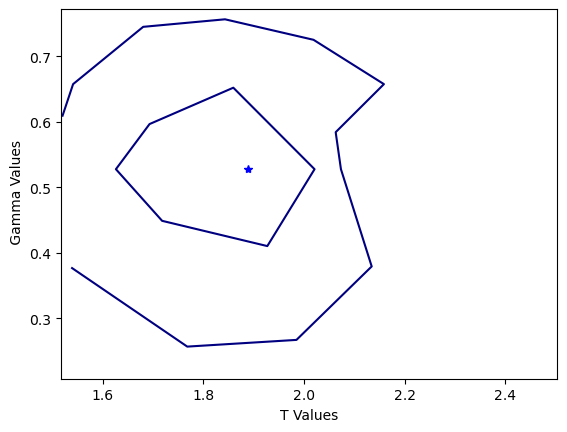

In [15]:
Gvals = np.zeros(( N + 1,N + 1))
Tvals = np.zeros((  N + 1,N + 1))
for i1 in range(N+1):
    for i2 in range (N+1):
        bb = 1 + 1.4*Bvals[i1][i2]
        G = ((3.634 * Bvals[i1][i2]) / bb) 
        T = (( (b0vals[i1][i2] / 13) ** 2) * (bb / 1 + 0.128* Bvals[i1][i2]) ** Bvals[i1][i2] ) ** (1 / bb)
        Gvals[i1][i2] = G 
        Tvals[i1][i2] = T
print(Gvals)
print(Tvals)
print(C_pair)
fig, ax = plt.subplots()
ax.set_xlabel("T Values")
ax.set_ylabel(" Gamma Values")
ax.contour(Tvals, Gvals, pvals, levels=[0.05, 0.32], colors = "#000080")
ax.plot([C_pair[0]],[C_pair[1]],"b*")

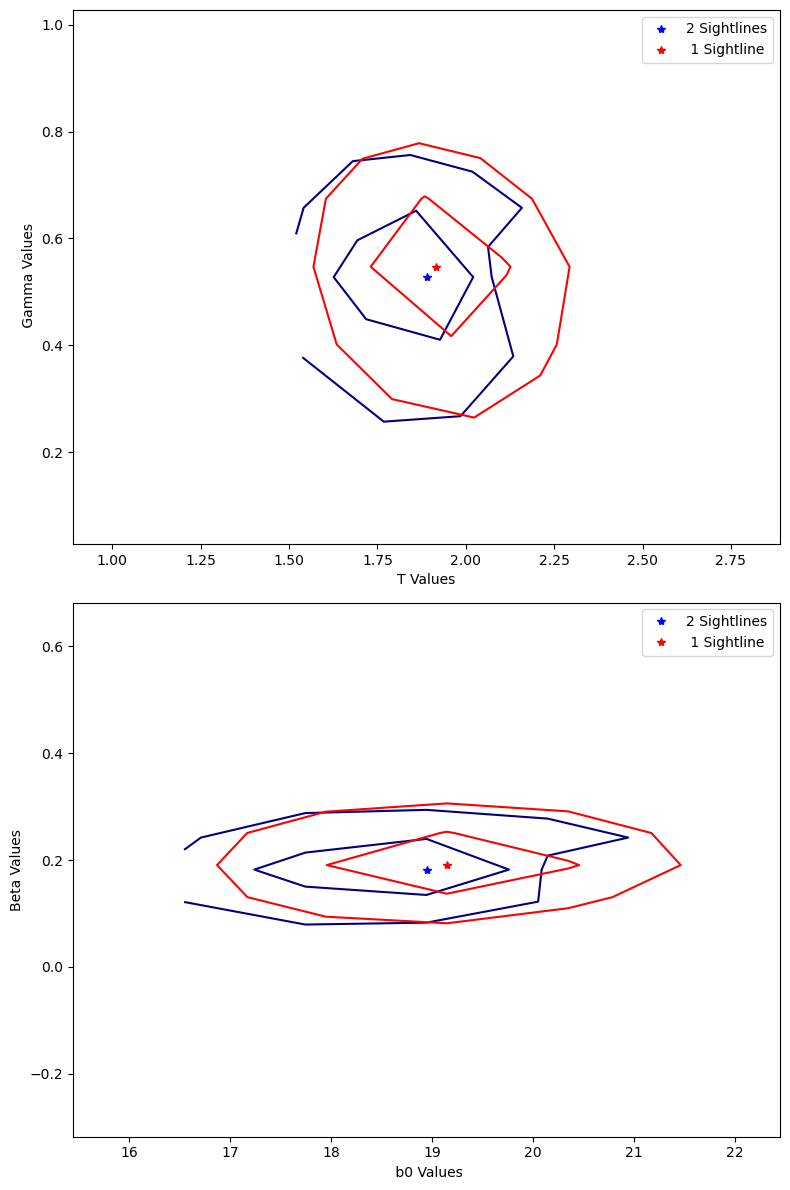

In [32]:
fig, ax = plt.subplots(2,figsize = (8,12))
B0vals2  = np.array([[16.5465578, 17.7465578, 18.9465578, 20.1465578, 21.3465578],
 [16.5465578, 17.7465578, 18.9465578, 20.1465578, 21.3465578],
 [16.5465578, 17.7465578, 18.9465578, 20.1465578, 21.3465578],
 [16.5465578, 17.7465578, 18.9465578, 20.1465578, 21.3465578],
 [16.5465578, 17.7465578, 18.9465578, 20.1465578, 21.3465578]] )
Bvals2 = nparray([[0.06226794, 0.06226794, 0.06226794, 0.06226794, 0.06226794],
 [0.12226794, 0.12226794, 0.12226794, 0.12226794, 0.12226794],
 [0.18226794, 0.18226794, 0.18226794, 0.18226794, 0.18226794],
 [0.24226794, 0.24226794, 0.24226794, 0.24226794, 0.24226794],
 [0.30226794, 0.30226794, 0.30226794, 0.30226794, 0.30226794]] )
Pvals2 =  np.array( [[2.50602346e-03, 3.56972911e-03, 2.44510718e-03, 8.90213359e-04,
  1.98046837e-04],
 [5.04530756e-02, 1.65883590e-01, 1.39969513e-01, 4.22897286e-02,
  7.07767581e-03],
 [8.00392365e-02, 4.94473462e-01, 1.00000000e+00, 4.95747443e-08,
  2.55481295e-02],
 [3.13654097e-02, 1.65609935e-01, 2.90184427e-01, 1.14915591e-01,
  1.71381509e-02],
 [5.02219333e-03, 1.42554236e-02, 1.22828612e-02, 5.06988436e-03,
  1.28296513e-03]] )
Gvals2 = np.array([[0.20813729, 0.20813729, 0.20813729, 0.20813729, 0.20813729],
 [0.37938109, 0.37938109, 0.37938109, 0.37938109, 0.37938109],
 [0.5277046,  0.5277046,  0.5277046,  0.5277046,  0.5277046 ],
 [0.65742088, 0.65742088, 0.65742088, 0.65742088, 0.65742088],
 [0.77182469, 0.77182469, 0.77182469,0.77182469, 0.77182469]])
Tvals2 = np.array([[1.56670892, 1.78207085, 2.01001938, 2.25042302, 2.50315963],
 [1.53698777, 1.73218841, 1.93696189, 2.1511267,  2.37451561],
 [1.52204116, 1.7016732,  1.88866359, 2.08281896, 2.28396247],
 [1.5177683,  1.68506329, 1.8580379,  2.03650676, 2.22030145],
 [1.52142596, 1.67873168, 1.84041091, 2.00629656, 2.17623761]])
b2 = (18.94655780286924, 0.18226793763492896)
c2 = (1.8886635893315167, 0.527704603659952)
B0Values1 = np.array([[16.74870987, 17.94870987, 19.14870987, 20.34870987, 21.54870987],
 [16.74870987, 17.94870987, 19.14870987, 20.34870987, 21.54870987],
 [16.74870987, 17.94870987, 19.14870987, 20.34870987, 21.54870987],
 [16.74870987, 17.94870987, 19.14870987, 20.34870987, 21.54870987],
 [16.74870987, 17.94870987, 19.14870987, 20.34870987, 21.54870987]])
BetaValues1 = np.array( [[0.07073621, 0.07073621, 0.07073621, 0.07073621, 0.07073621],
 [0.13073621, 0.13073621, 0.13073621, 0.13073621, 0.13073621],
 [0.19073621, 0.19073621, 0.19073621, 0.19073621, 0.19073621],
 [0.25073621, 0.25073621, 0.25073621, 0.25073621, 0.25073621],
 [0.31073621, 0.31073621, 0.31073621, 0.31073621, 0.31073621]] )

Gvals1 = np.array( [[0.23389283, 0.23389283, 0.23389283, 0.23389283, 0.23389283],
 [0.40159177, 0.40159177, 0.40159177, 0.40159177, 0.40159177],
 [0.54705494, 0.54705494, 0.54705494, 0.54705494, 0.54705494],
 [0.67442983, 0.67442983, 0.67442983, 0.67442983, 0.67442983],
 [0.78689285, 0.78689285, 0.78689285, 0.78689285, 0.78689285]] )
                  
Tvals1 = np.array([[1.59629952, 1.81051594, 2.03680641, 2.27503082, 2.52505906],
 [1.56591502, 1.76024488, 1.96376184, 2.17628359, 2.39764221],
 [1.55029891, 1.72922753, 1.91521587, 2.10807374, 2.30762725],
 [1.54538683, 1.71208193, 1.88422045, 2.06162218, 2.24412334],
 [1.54844917, 1.70521918, 1.86617294, 2.0311493, 2.20000257]])
pvals1= np.array( [[1.35749539e-03, 5.92640155e-03, 7.47914884e-03, 2.39544084e-03,
  2.90786573e-04],
 [1.23856635e-02, 1.18731893e-01, 2.38400922e-01, 7.51428450e-02,
  6.40703939e-03],
 [1.96381408e-02, 3.14378214e-01, 1.00000000e+00, 3.49201832e-01,
  2.70362876e-02],
 [1.10565294e-02, 1.21844955e-01, 3.32304352e-01, 1.31630517e-01,
  1.28160632e-02],
 [2.43704504e-03, 1.39296238e-02, 2.69138786e-02, 1.08970838e-02,
  1.41791830e-03]] )
C1 = (1.9152158659599539, 0.5470549358761017)

ax[0].set_xlabel("T Values")
ax[0].set_ylabel(" Gamma Values")
ax[0].set_xlim(C_pair[0] - 1, C_pair[0]+1)
ax[0].set_ylim(C_pair[1] - 0.5,C_pair[1]+0.5)
ax[0].contour(Tvals, Gvals, pvals, levels=[0.05, 0.32], colors = "#000080")
ax[0].plot([C_pair[0]],[C_pair[1]],"b*")
ax[0].contour(Tvals1, Gvals1, pvals1, levels=[0.05, 0.32], colors = "r")
ax[0].plot([C1[0]],[C1[1]],"r*")

ax[1].set_ylabel("Beta Values")
ax[1].set_xlabel(" b0 Values")
ax[1].set_xlim(res.x[0]-3.5,res.x[0]+3.5)
ax[1].set_ylim(res.x[1]-0.5,res.x[1]+0.5)
ax[1].contour(b0vals, Bvals, pvals, levels=[0.05,0.32], colors = "#000080")
ax[1].plot([res.x[0]],[res.x[1]],"b*")
ax[1].contour(B0Values1, BetaValues1, pvals1, levels=[0.05,0.32],colors = "r")
ax[1].plot(19.14870986832592,0.19073621276111663,"r*")

ax[0].legend(['2 Sightlines',' 1 Sightline'])
ax[1].legend(['2 Sightlines',' 1 Sightline'])
fig.tight_layout()
plt.savefig("ASTR 2-1 Sightlines", dpi=300)